## Number of crossings vs number of ribbons

In [88]:
import pandas as pd
import numpy as np

import seaborn as sb
import matplotlib.pyplot as plt


In [89]:
linkinfo = pd.read_csv('/Users/seohyeonlee/knotinfo/results/cleaned_linkinfo_original_columns.csv')
df_1214 = pd.read_csv('/Users/seohyeonlee/knotinfo/results/snappy_links_12_to_14_crossings.csv')


In [109]:
linkinfo.head()
linkinfo.describe()
linkinfo_short = linkinfo[['name_unoriented', 'crossing_number']]
df_1214_short = df_1214[['name_unoriented', 'num_crossings']]


In [ ]:
low_crossings = linkinfo_short.value_counts('crossing_number')
higher_crossings = df_1214_short.value_counts('num_crossings')
links_by_crossings = pd.concat([low_crossings, higher_crossings], axis=0).sort_values()


AttributeError: module 'seaborn' has no attribute 'set_xlabel'

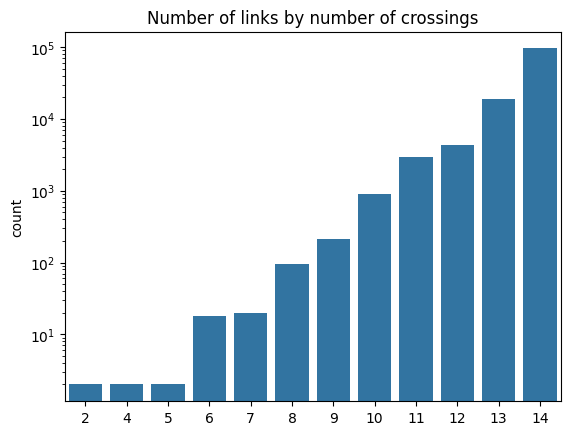

In [ ]:
sb.barplot(links_by_crossings, log=True)
plt.title('Number of links by number of crossings')
plt.xlabel('# crossings')
plt.ylabel('# links')
plt.show()



In [ ]:
#get known ribbons

passed_obstructions = pd.read_csv('/Users/seohyeonlee/knotinfo/results/census_checked.csv')
known_ribbons_short = passed_obstructions[passed_obstructions['known_ribbon'] == True][['name_unoriented', 'num_crossings']]
num_known_ribbons = known_ribbons_short.value_counts('num_crossings').sort_values()
num_passed_obstructions = passed_obstructions.value_counts('num_crossings').sort_values()


In [ ]:
#known_ribbons_by_crossings = pd.Series(np.zeros(len(links_by_crossings)), index=links_by_crossings.index)
#passed_obstructions_by_crossings = pd.Series(np.zeros(len(links_by_crossings)), index=links_by_crossings.index)

def fill_in_values(info, target):
    new_series = pd.Series(np.zeros(len(target)), index=target.index, dtype=int)
    for idx, item in zip(info.index, info):
        #print(f'idx, item {idx} {item}')
        new_series[idx] = item
        #print(f'new series udx {idx} updated to {new_series[idx]} ')
    return new_series

known_ribbons_by_crossings = fill_in_values(num_known_ribbons, links_by_crossings)
passed_obstructions_by_crossings = fill_in_values(num_passed_obstructions, links_by_crossings)




In [ ]:
df = pd.concat([links_by_crossings, passed_obstructions_by_crossings, known_ribbons_by_crossings], axis=1)
df.columns = ['link_counts', 'num_passed_obstructions', 'known_ribbons']
df.tail()


,link_counts,num_passed_obstructions,known_ribbons
10,914,2,2
11,2920,0,0
12,4276,10,9
13,18883,11,9
14,95991,71,52


TypeError: 'str' object is not callable

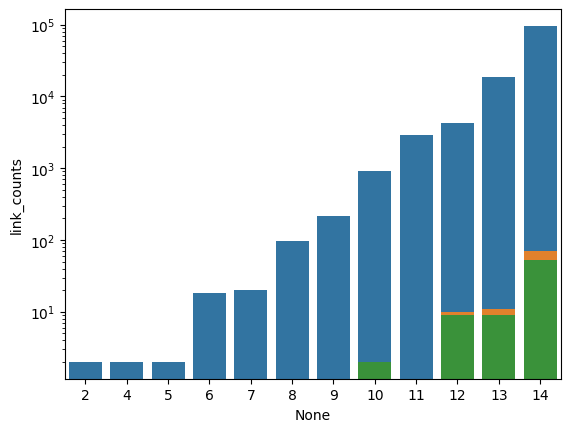

In [ ]:
sb.barplot(x=df.index, y=df.iloc[:, 0], log=True)
sb.barplot(x=df.index, y=df.iloc[:, 1], log=True)
sb.barplot(x=df.index, y=df.iloc[:, 2], log=True)

plt.xlabel("number of crossings")
plt.legend(df.columns)


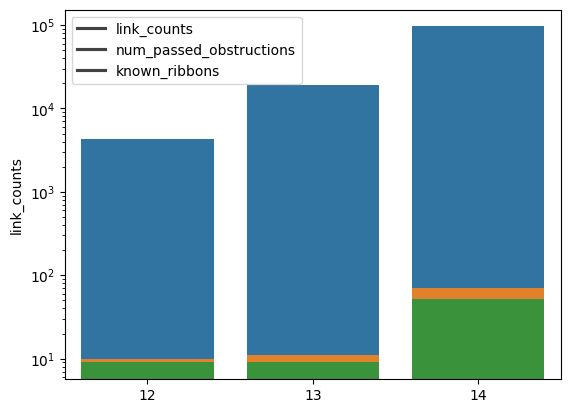

In [ ]:
sb.barplot(x=range(12, 15), y=df.loc[range(12, 15), df.columns[0]], log=True)
sb.barplot(x=range(12, 15), y=df.loc[range(12, 15), df.columns[1]], log=True)
sb.barplot(x=range(12, 15), y=df.loc[range(12, 15), df.columns[2]], log=True)

plt.xlabel = "number of crossings"
plt.legend(df.columns)


- Link count grows exponentially (?) over number of crossings. 
- No ribbons in <=9 and 11 crossings (why)?. 
- Number of known ribbons / number of ribbons that passed all obstructions grow faster than exponential. 
- No links of 1 and 3 crossings. 